
# 真假新聞辨識 — 分析工作簿

本筆記本讀取 `final.json`，提供：  
1. **功能一**：`label × credibility` 四分類圓餅圖  
2. **功能二**：依定義簡易計算整體**準確率**（平均分數）  


## 前處理

將指定資料夾中的 XX_final.json 檔案（例如 1_final.json, 2_final.json ...）
依數字順序串聯成一個 final.json。

In [18]:
import os
import re
import json
import glob

# ======= 可修改路徑 =======
INPUT_DIR = r"..\result1"   # 放 XX_final.json 的資料夾
OUTPUT_FILE = r".\final.json"  # 輸出檔案路徑
# =============================

def numeric_key(path: str) -> int:
    """從檔名抽出數字作排序 key"""
    name = os.path.basename(path)
    m = re.match(r"(\d+)_final\.json$", name)
    return int(m.group(1)) if m else 10**9

def main():
    pattern = os.path.join(INPUT_DIR, "*_final.json")
    files = glob.glob(pattern)
    files.sort(key=numeric_key)

    data = []
    errors = []

    for fp in files:
        try:
            with open(fp, "r", encoding="utf-8") as f:
                obj = json.load(f)
            data.append(obj)
        except Exception as e:
            errors.append({"file": os.path.basename(fp), "error": str(e)})

    # 寫出 final.json
    os.makedirs(os.path.dirname(OUTPUT_FILE) or ".", exist_ok=True)
    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"[OK] 合併完成：{len(files)} 檔 → {OUTPUT_FILE}")
    if errors:
        print(f"[WARN] 讀取失敗 {len(errors)} 筆：")
        for e in errors:
            print(" -", e)

if __name__ == "__main__":
    main()


[OK] 合併完成：52 檔 → .\final.json


## 基本設定（依需要修改）

In [ ]:
INPUT_JSON = r".\final.json"        # final.json 路徑
THRESHOLD = 50
THRESHOLD_INCLUSIVE = False  # True: >= 50 視為「判斷為真」；False: > 50
print("INPUT_JSON :", INPUT_JSON)
print("THR        :", THRESHOLD, "(inclusive)" if THRESHOLD_INCLUSIVE else "(exclusive)")


INPUT_JSON : .\final.json
THR        : 50 (exclusive)


In [ ]:
import os, json, math
from typing import List, Dict, Any
import matplotlib
import matplotlib.pyplot as plt

# 設定中文字型（依序嘗試）
for f in ['Microsoft JhengHei', 'SimHei', 'PingFang TC', 'Noto Sans CJK TC', 'Noto Sans CJK SC', 'Arial Unicode MS']:
    try:
        matplotlib.rcParams['font.sans-serif'] = [f]
        matplotlib.rcParams['axes.unicode_minus'] = False
        print("使用字型：", f)
        break
    except Exception:
        pass


使用字型： Microsoft JhengHei


In [7]:

def load_data(path: str):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError("final.json 格式需為 JSON 陣列（list）。")
    return data

rows = load_data(INPUT_JSON)
len(rows)


52

In [8]:

def to_float(x) -> float:
    if x is None:
        return math.nan
    try:
        return float(x)
    except Exception:
        return math.nan


## 功能一：`label × credibility` 四分類圓餅圖

A 判真/實真: 36
B 判真/實假: 6
C 判假/實真: 6
D 判假/實假: 4
有效樣本: 52 ；略過: 0 ；總筆數: 52


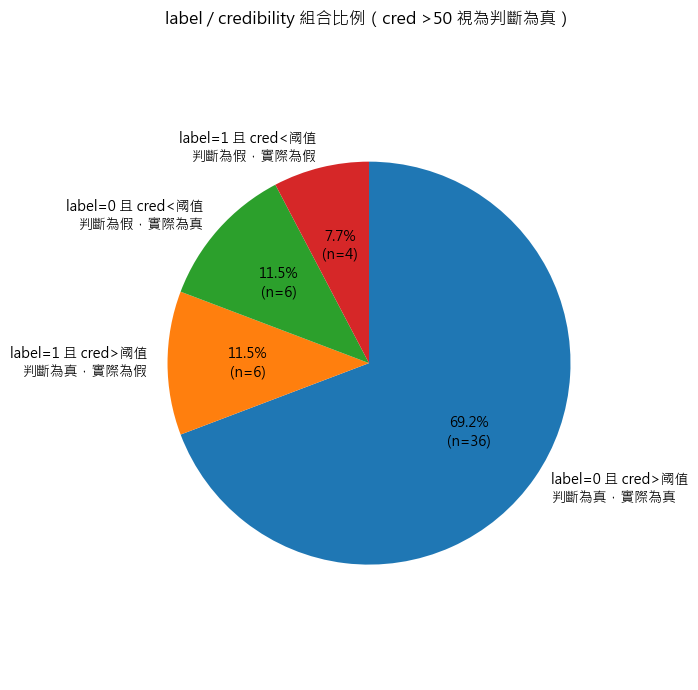

已輸出： .\pie_label_credibility.png


<Figure size 640x480 with 0 Axes>

In [9]:
from typing import Tuple
from matplotlib import pyplot as plt

OUTPUT_PNG  = r".\pie_label_credibility.png"  # 圓餅圖輸出

def classify_counts(rows: List[Dict[str, Any]]) -> Tuple[int,int,int,int,int]:
    # A: label=0 & cred>thr   判斷為真，實際為真
    # B: label=1 & cred>thr   判斷為真，實際為假
    # C: label=0 & cred<thr   判斷為假，實際為真
    # D: label=1 & cred<thr   判斷為假，實際為假
    A = B = C = D = 0
    skipped = 0
    for r in rows:
        label = r.get("label", None)
        cred = to_float(r.get("credibility", None))
        if label not in (0, 1) or math.isnan(cred):
            skipped += 1
            continue
        judged_true = (cred >= THRESHOLD) if THRESHOLD_INCLUSIVE else (cred > THRESHOLD)
        if judged_true and label == 0: A += 1
        elif judged_true and label == 1: B += 1
        elif not judged_true and label == 0: C += 1
        elif not judged_true and label == 1: D += 1
    return (A, B, C, D, skipped)

A, B, C, D, skipped = classify_counts(rows)
total = A + B + C + D
total_all = total + skipped
print("A 判真/實真:", A)
print("B 判真/實假:", B)
print("C 判假/實真:", C)
print("D 判假/實假:", D)
print("有效樣本:", total, "；略過:", skipped, "；總筆數:", total_all)

labels = [
    "label=0 且 cred>阈值\n判斷為真，實際為真" if not THRESHOLD_INCLUSIVE else "label=0 且 cred≥阈值\n判斷為真，實際為真",
    "label=1 且 cred>阈值\n判斷為真，實際為假" if not THRESHOLD_INCLUSIVE else "label=1 且 cred≥阈值\n判斷為真，實際為假",
    "label=0 且 cred<阈值\n判斷為假，實際為真",
    "label=1 且 cred<阈值\n判斷為假，實際為假",
]
sizes = [A, B, C, D]
total = sum(sizes) if sum(sizes) > 0 else 1

def autopct_fmt(pct):
    count = int(round(pct/100.0 * total))
    return f"{pct:.1f}%\n(n={count})"

fig, ax = plt.subplots(figsize=(7,7))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=autopct_fmt,
    startangle=90,
    counterclock=False
)
ax.axis("equal")
title_thr = f">{THRESHOLD}" if not THRESHOLD_INCLUSIVE else f">={THRESHOLD}"
ax.set_title(f"label / credibility 組合比例（cred {title_thr} 視為判斷為真）", pad=16)
plt.tight_layout()
plt.show()
os.makedirs(os.path.dirname(OUTPUT_PNG) or ".", exist_ok=True)
plt.savefig(OUTPUT_PNG, dpi=200)
print("已輸出：", OUTPUT_PNG)


## 功能二：計算整體準確率（同時計算「線性版」與「平方距離版」）


1. **線性版**：  
  - `label=0` → `score = credibility/100`  
  - `label=1` → `score = 1 - credibility/100`  

2. **平方距離版**：令 `x = credibility/100`  
  - `label=0` → `score = x^2`  
  - `label=1` → `score = (x-1)^2`
  - 統一公式： `score = (x - y)^2`，其中 `y` 為 label (0/1)。  
  - 兩種分數均落在 [0,1]，將分別計算「平均分數」作為整體準確率。
  - 也可以改成 `x^4`，更嚴格


- 平方距離版 - 曲線圖片

![Credibility Hist](square_distance_version.png)

In [6]:

def per_sample_score_linear(label, cred):
    from math import isnan
    c = to_float(cred)
    if label not in (0, 1) or isnan(c):
        return None
    c = max(0.0, min(100.0, c))
    return (c/100.0) if label == 0 else (1.0 - c/100.0)

def per_sample_score_squared(label, cred):
    from math import isnan
    c = to_float(cred)
    if label not in (0, 1) or isnan(c):
        return None
    x = max(0.0, min(100.0, c)) / 100.0  # normalize [0,1]
    y = label
    s = (x - y)**2
    return max(0.0, min(1.0, s))

lin_scores, sq_scores = [], []
skipped_lin = skipped_sq = 0

for r in rows:
    s1 = per_sample_score_linear(r.get("label"), r.get("credibility"))
    s2 = per_sample_score_squared(r.get("label"), r.get("credibility"))
    if s1 is None: skipped_lin += 1
    else: lin_scores.append(s1)
    if s2 is None: skipped_sq += 1
    else: sq_scores.append(s2)

acc_linear = sum(lin_scores) / len(lin_scores) if lin_scores else 0.0
acc_squared = sum(sq_scores) / len(sq_scores) if sq_scores else 0.0

print(f"[線性版] 有效樣本：{len(lin_scores)} ；略過：{skipped_lin} ；整體準確率：{acc_linear:.4f}  ({acc_linear*100:.2f}%)")
print(f"[平方距離版] 有效樣本：{len(sq_scores)} ；略過：{skipped_sq} ；整體準確率：{acc_squared:.4f}  ({acc_squared*100:.2f}%)")


[線性版] 有效樣本：52 ；略過：0 ；整體準確率：0.7342  (73.42%)
[平方距離版] 有效樣本：52 ；略過：0 ；整體準確率：0.6089  (60.89%)


## 功能三：段落之可用搜尋結果(search)數量圓餅圖

=== 段落 search 數量分佈 ===
0: 29
1: 58
2: 39
3: 24
4: 29
5: 116
總段落數： 295


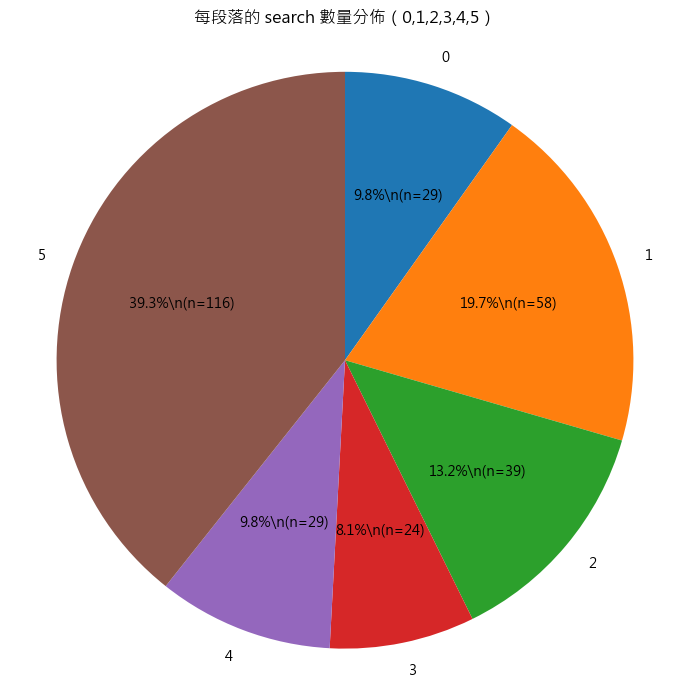

已輸出： ./pie_paragraph_search_counts.png


<Figure size 640x480 with 0 Axes>

In [10]:
from collections import Counter
import matplotlib.pyplot as plt
import os

PARA_PIE_OUT = r"./pie_paragraph_search_counts.png"

def iter_paragraphs(row):
    paras = row.get("paragraph", [])
    if isinstance(paras, list):
        for p in paras:
            yield p
    elif isinstance(paras, dict):
        for _, p in paras.items():
            yield p

def count_search_len(p):
    """回傳 search 的有效數量（空 dict 不算）。"""
    if isinstance(p, dict):
        s = p.get("search", [])
        if isinstance(s, list):
            # 過濾掉空的 dict
            valid = [x for x in s if not (isinstance(x, dict) and len(x) == 0)]
            return len(valid)
    return 0

# 收集所有段落的 search 數量
bins = Counter()
total_paragraphs = 0
for r in rows:
    for p in iter_paragraphs(r):
        total_paragraphs += 1
        k = count_search_len(p)
        k = min(k, 5)  # clip 到 5+
        bins[k] += 1

# 準備圖表資料
labels = ["0", "1", "2", "3", "4", "5"]
sizes = [bins.get(0,0), bins.get(1,0), bins.get(2,0), bins.get(3,0), bins.get(4,0), bins.get(5,0)]
total = sum(sizes) if sum(sizes) > 0 else 1

def autopct_fmt(pct):
    count = int(round(pct/100.0 * total))
    return f"{pct:.1f}%\\n(n={count})"

print("=== 段落 search 數量分佈 ===")
for lab, cnt in zip(labels, sizes):
    print(f"{lab}: {cnt}")
print("總段落數：", total_paragraphs)

# 畫圓餅圖
fig, ax = plt.subplots(figsize=(7,7))
ax.pie(
    sizes,
    labels=labels,
    autopct=autopct_fmt,
    startangle=90,
    counterclock=False
)
ax.axis("equal")
ax.set_title("每段落的 search 數量分佈（0,1,2,3,4,5）", pad=16)
plt.tight_layout()
plt.show()

# 輸出圖檔
os.makedirs(os.path.dirname(PARA_PIE_OUT) or ".", exist_ok=True)
plt.savefig(PARA_PIE_OUT, dpi=200)
print("已輸出：", PARA_PIE_OUT)


## 功能四：真與假新聞分析分數之分鋪長條圖


1. label = 0，實際為真，的 credibility 分鋪長條圖，每 10 分一個區間
2. label = 1，實際為假，的 credibility 分鋪長條圖，每 10 分一個區間

label=0 (實際真) 样本數: 42
label=1 (實際假) 样本數: 10


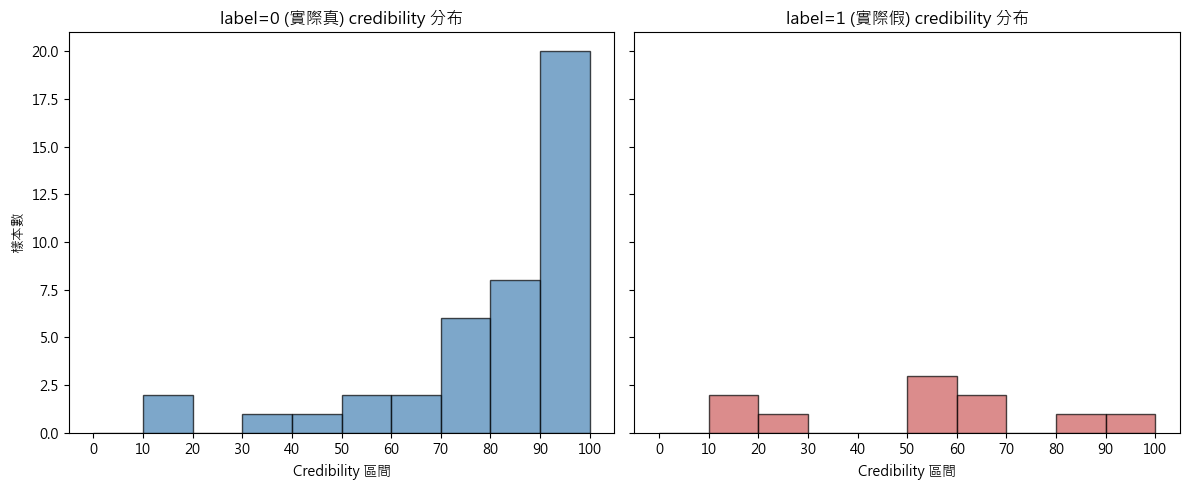

已輸出： .\hist_credibility_by_label.png


<Figure size 640x480 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os

HIST_OUT = r".\hist_credibility_by_label.png"

# 收集不同 label 的 credibility
cred0, cred1 = [], []
for r in rows:
    c = to_float(r.get("credibility"))
    if np.isnan(c): 
        continue
    if r.get("label") == 0:
        cred0.append(c)
    elif r.get("label") == 1:
        cred1.append(c)

print(f"label=0 (實際真) 样本數: {len(cred0)}")
print(f"label=1 (實際假) 样本數: {len(cred1)}")

# 分組區間 (0~100, 每 10 分一格)
bins = np.arange(0, 110, 10)

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# label=0 的直方圖
axes[0].hist(cred0, bins=bins, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_title("label=0 (實際真) credibility 分布")
axes[0].set_xlabel("Credibility 區間")
axes[0].set_ylabel("樣本數")
axes[0].set_xticks(bins)

# label=1 的直方圖
axes[1].hist(cred1, bins=bins, color="indianred", edgecolor="black", alpha=0.7)
axes[1].set_title("label=1 (實際假) credibility 分布")
axes[1].set_xlabel("Credibility 區間")
axes[1].set_xticks(bins)

plt.tight_layout()
plt.show()

# 輸出檔案
os.makedirs(os.path.dirname(HIST_OUT) or ".", exist_ok=True)
plt.savefig(HIST_OUT, dpi=200)
print("已輸出：", HIST_OUT)
